In [ ]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 69.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=2144072650ca646a9fe532b57f10cce890fdef40321a5667532e37eca58ef420
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


Final key : [-1, -1, 1, 1, -1, -1, 1, -1, 1, 1, -1, -1, -1, 1, -1, -1, -1, 1, 1, -1, -1, 1, 1, 1, -1, -1, -1]
S  = 0.646 <= 2, complete quantum correlation lost
Final key : [-1, -1, 1, 1, -1, -1, 1, -1, 1, 1, -1, -1, -1, 1, -1, -1, -1, 1, 1, -1, -1, 1, 1, 1, -1, -1, -1]


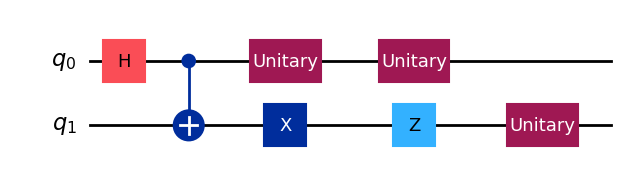

In [9]:
from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math
import numpy as np

# The aim of the assignment is to simulate the Ekert91 key distribution protocol.

# This notebook is for a simulation of the protocol without an attacker.

def random():
  circuit = QuantumCircuit(1,1)
  circuit.h(0)

  state = Statevector.from_int(0,2)
  state = state.evolve(circuit)
  counts = state.sample_counts(1)
  return int(list(counts.keys())[0])

def entangled_pair():
  circuit = QuantumCircuit(2)
  circuit.h(0)
  circuit.cx(0,1)
  circuit.x(1)
  circuit.z(1)
  return circuit

def random_3_choice():
  state = Statevector([1/math.sqrt(3), math.sqrt(2)/math.sqrt(3)])
  counts = state.sample_counts(1)

  qubit = int(list(counts.keys())[0])

  if qubit == 0:
    return 0

  state = Statevector([1/math.sqrt(2), 1/math.sqrt(2)])
  counts = state.sample_counts(1)
  qubit = int(list(counts.keys())[0])
  if qubit == 0:
    return 1
  else:
    return 2

X = np.array([
    [0,1],
    [1,0]
])
Z = np.array([
    [1,0],
     [0,-1]
])
W = (X + Z)/math.sqrt(2)
V = (X - Z)/math.sqrt(2)

ops = {
    'X': X,
    'Z': Z,
    'W': W,
    'V': V
}

def measurement_unitary(A):
    eigvals, eigvecs = np.linalg.eigh(A)
    idx = np.argsort(eigvals)[::-1]
    eigvecs = eigvecs[:,idx]
    return eigvecs.conj().T

def apply_measurement(circuit, qubit, basis):
    U = measurement_unitary(ops[basis])
    gate = QuantumCircuit(1)
    gate.unitary(U,[0])
    circuit.compose(gate, qubits=[qubit], inplace=True)

def attack(circuit, qubit):
  basis = 'X'
  idx = (random(), random())
  if idx == (0,1):
    basis = 'Z'
  elif idx == (1,0):
    basis = 'W'
  elif idx == (1,1):
    basis = 'V'
  apply_measurement(circuit, qubit, basis)

def average(results, alice_basis, bob_basis):
  matched = [result['alice_bit'] * result['bob_bit']
             for result in results
             if result['alice_basis'] == alice_basis and result['bob_basis'] == bob_basis
            ]
  if len(matched) == 0:
    return 0

  return sum(matched) / len(matched)

def calculate_S(qubits):
  xw = average(qubits, 'X','W')
  xv = average(qubits, 'X','V')
  zw = average(qubits, 'Z','W')
  zv = average(qubits, 'Z','V')

  S = abs(xw + xv + zw - zv)
  return S

N = 20

a_ops = ['X','W','Z']
b_ops = ['W', 'Z', 'V']
sequence = []
first_qc = QuantumCircuit(2)
for i in range(int(9 * N /2)):
  qc = entangled_pair()

  alice_i = random_3_choice()
  bob_j = random_3_choice()

  a_basis = a_ops[alice_i]
  b_basis = b_ops[bob_j]

  apply_measurement(qc, 0, a_basis)
  attack(qc, 0)
  apply_measurement(qc, 1, b_basis)

  if i == 0:
    first_qc = qc

  state = Statevector.from_label('00')
  state = state.evolve(qc)

  counts = state.sample_counts(1)
  result = list(counts.keys())[0]
  alice_bit = (-1) ** int(result[-1])
  bob_bit = (-1) ** int(result[-2])
  sequence.append({
      'alice_i' : alice_i,
      'alice_basis': a_ops[alice_i],
      'alice_bit': alice_bit,
      'bob_j': bob_j,
      'bob_basis': b_ops[bob_j],
      'bob_bit': bob_bit
  })


final_key = []
S_list = []
for i in sequence:
  if (i['alice_i'] == 1 and i['bob_j'] == 0) or (i['alice_i'] == 2 and i['bob_j'] == 1):
    final_key.append(i['alice_bit'])
  else:
    S_list.append(i)

S = calculate_S(S_list)

print(f"Final key : {final_key}")

if abs(S - 2 * math.sqrt(2)) < 0.5:
  print(f"S = {S:.3f} Entanlged confirmed")
elif abs(S) <= 2:
  print(f"S  = {S:.3f} <= 2, complete quantum correlation lost")
else:
  print(f"S = {S:.3f}, significant difference to 2 root 2, possible eavesdropper")

print(f"Final key : {final_key}")

first_qc.draw("mpl")